##Problem 1 - Make_blobs data

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_blobs
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

In [ ]:
X,y = make_blobs(n_samples=1000, n_features=2, centers=3)

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [ ]:
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

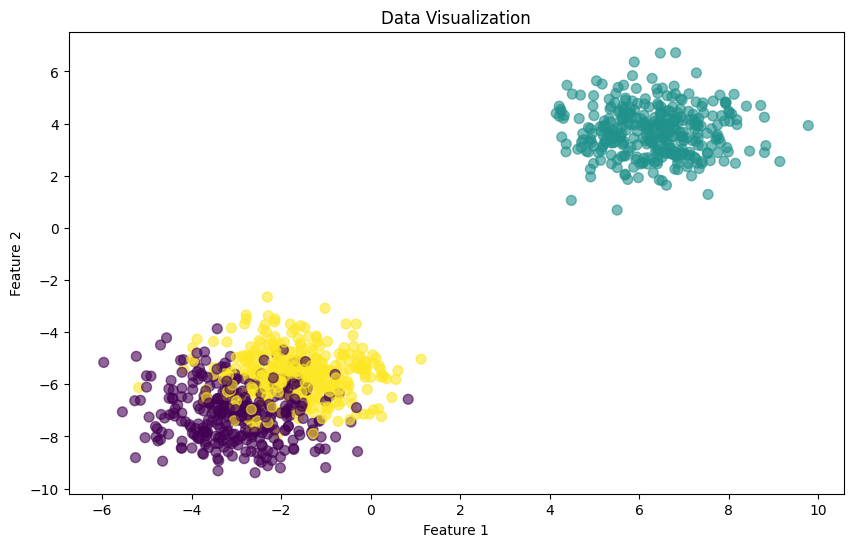

In [ ]:
plt.figure(figsize=(10,6))
plt.scatter(X[:,0], X[:,1], c=y, cmap='viridis', alpha=0.6, s=50)
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.title('Data Visualization')
plt.show()

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim

In [ ]:
X_train = torch.tensor(X_train, dtype=torch.float32)
X_test = torch.tensor(X_test, dtype=torch.float32)
y_train = torch.tensor(y_train, dtype=torch.long)
y_test = torch.tensor(y_test, dtype=torch.long)

In [ ]:
model = nn.Sequential(nn.Linear(2,3))
criterion = nn.CrossEntropyLoss()
optimizer = optim.SGD(model.parameters(), lr=0.1)

In [ ]:
epochs = 500

for epoch in range(epochs):
  y_hat = model(X_train)
  loss = criterion(y_hat, y_train)

  optimizer.zero_grad()
  loss.backward()
  optimizer.step()

  if epoch%100 == 0:
      with torch.no_grad():
        train_preds = torch.argmax(y_hat,dim=1)
        train_acc = (train_preds == y_train).float().mean() * 100
        print(f"Epoch:{epoch}, Loss:{loss.item()}, Acc:{train_acc}")

Epoch:0, Loss:1.21761155128479, Acc:33.75
Epoch:100, Loss:0.46211403608322144, Acc:81.625
Epoch:200, Loss:0.4180278778076172, Acc:86.625
Epoch:300, Loss:0.39037299156188965, Acc:87.625
Epoch:400, Loss:0.36966362595558167, Acc:89.125


In [ ]:
model.eval()

with torch.no_grad():
  train_preds = torch.argmax(model(X_train),dim=1)
  test_preds = torch.argmax(model(X_test),dim=1)
  train_acc = (train_preds == y_train).float().mean() * 100
  test_acc = (test_preds == y_test).float().mean() * 100

print(f"Training Accuracy : {train_acc.item()}%")
print(f"Test Accuracy : {test_acc.item()}%")

Training Accuracy : 89.5%
Test Accuracy : 90.0%


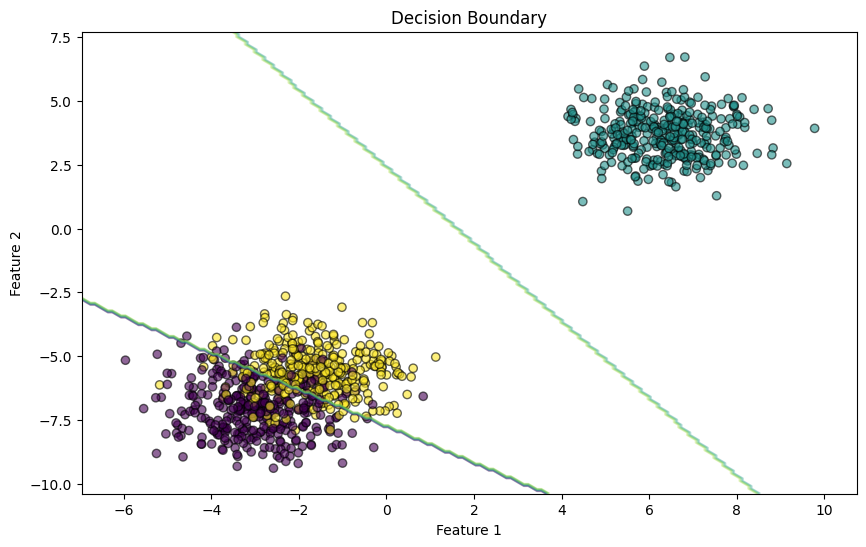

In [ ]:
x_min,x_max = X[:,0].min()-1, X[:,0].max()+1
y_min,y_max = X[:,1].min()-1, X[:,1].max()+1

xx,yy = np.meshgrid(np.arange(x_min,x_max,0.1), np.arange(y_min,y_max,0.1))
grid = np.c_[xx.ravel(),yy.ravel()]

grid_scaled = scaler.transform(grid)
grid_scaled = torch.tensor(grid_scaled, dtype=torch.float32)

with torch.no_grad():
  Z = torch.argmax(model(grid_scaled),dim=1)
  Z = Z.reshape(xx.shape)

plt.figure(figsize=(10,6))
plt.contour(xx, yy, Z.numpy(), alpha=0.3)
plt.scatter(X[:,0], X[:,1], c=y, cmap='viridis', alpha=0.6, edgecolor='k')
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.title('Decision Boundary')
plt.show()

##Problem 2 - XoR data

In [ ]:
X_train = torch.tensor([[0,0],[0,1],[1,0],[1,1]], dtype=torch.float32)
y_train = torch.tensor([0,1,1,0], dtype=torch.int64)

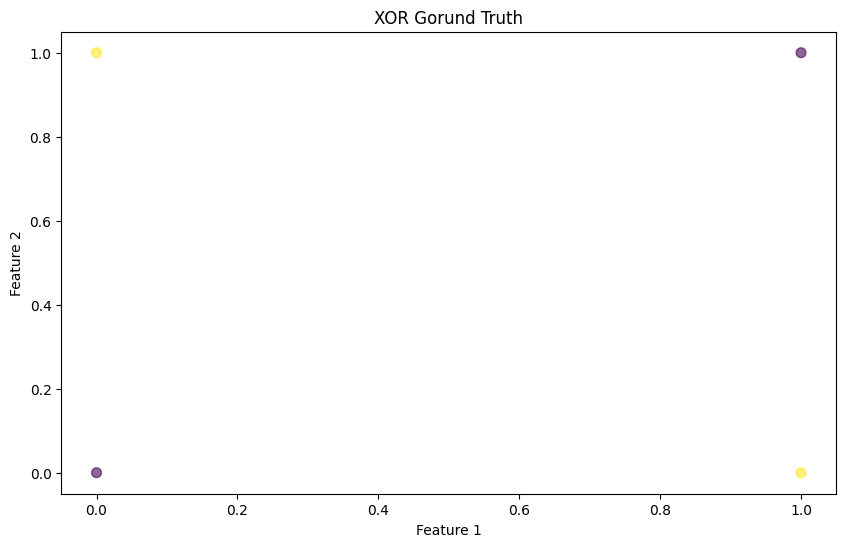

In [ ]:
plt.figure(figsize=(10,6))
plt.scatter(X_train[:,0], X_train[:,1], c=y_train, cmap='viridis', alpha=0.6, s=50)
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.title('XOR Gorund Truth')
plt.show()

In [ ]:
model = nn.Sequential(nn.Linear(2,2), nn.Tanh(),nn.Linear(2,2))
criterion = nn.CrossEntropyLoss()
optimizer = optim.SGD(model.parameters(), lr=0.1)

In [ ]:
epochs = 2000

for epoch in range(epochs):
  y_hat = model(X_train)
  loss = criterion(y_hat, y_train)

  optimizer.zero_grad()
  loss.backward()
  optimizer.step()

  if epoch%100 == 0:
      with torch.no_grad():
        train_preds = torch.argmax(y_hat,dim=1)
        train_acc = (train_preds == y_train).float().mean() * 100
        print(f"Epoch:{epoch}, Loss:{loss.item()}, Acc:{train_acc}")

Epoch:0, Loss:0.7697334289550781, Acc:50.0
Epoch:100, Loss:0.6929043531417847, Acc:50.0
Epoch:200, Loss:0.6919384002685547, Acc:50.0
Epoch:300, Loss:0.686703622341156, Acc:75.0
Epoch:400, Loss:0.6581403613090515, Acc:75.0
Epoch:500, Loss:0.5894849300384521, Acc:75.0
Epoch:600, Loss:0.491801381111145, Acc:75.0
Epoch:700, Loss:0.35417479276657104, Acc:100.0
Epoch:800, Loss:0.20925575494766235, Acc:100.0
Epoch:900, Loss:0.12408248335123062, Acc:100.0
Epoch:1000, Loss:0.08193780481815338, Acc:100.0
Epoch:1100, Loss:0.05932649224996567, Acc:100.0
Epoch:1200, Loss:0.04582173749804497, Acc:100.0
Epoch:1300, Loss:0.03702961653470993, Acc:100.0
Epoch:1400, Loss:0.03092033788561821, Acc:100.0
Epoch:1500, Loss:0.026459714397788048, Acc:100.0
Epoch:1600, Loss:0.023075096309185028, Acc:100.0
Epoch:1700, Loss:0.020427361130714417, Acc:100.0
Epoch:1800, Loss:0.01830419898033142, Acc:100.0
Epoch:1900, Loss:0.016566738486289978, Acc:100.0


In [ ]:
model.eval()

with torch.no_grad():
  train_preds = torch.argmax(model(X_train),dim=1)
  train_acc = (train_preds == y_train).float().mean() * 100

print(f"Training Accuracy : {train_acc.item()}%")

Training Accuracy : 100.0%


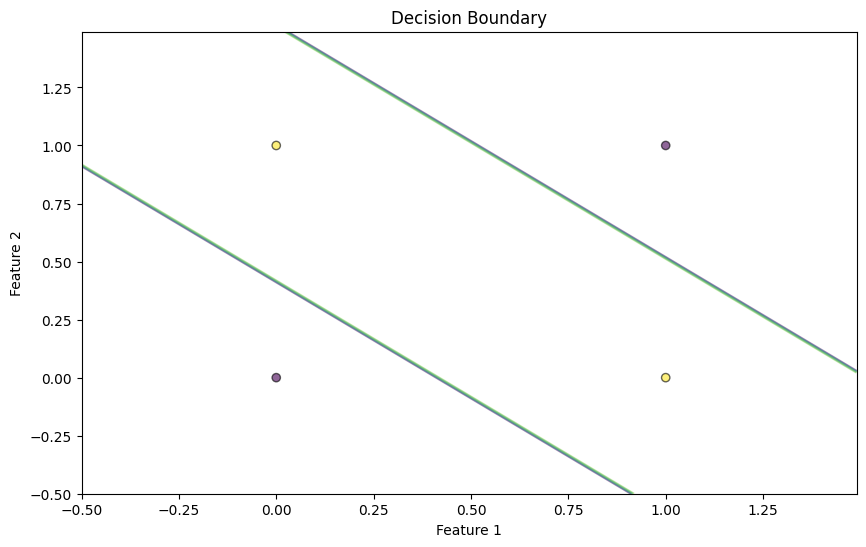

In [ ]:
X_np = X_train.numpy()
y_np = y_train.numpy()

x_min,x_max = X_np[:,0].min()-0.5, X_np[:,0].max()+0.5
y_min,y_max = X_np[:,1].min()-0.5, X_np[:,1].max()+0.5

xx,yy = np.meshgrid(np.arange(x_min,x_max,0.01), np.arange(y_min,y_max,0.01))
grid = np.c_[xx.ravel(),yy.ravel()]
grid_tensor = torch.tensor(grid, dtype=torch.float32)

with torch.no_grad():
  Z = torch.argmax(model(grid_tensor),dim=1)
  Z = Z.reshape(xx.shape)

plt.figure(figsize=(10,6))
plt.contour(xx, yy, Z.numpy(), alpha=0.3)
plt.scatter(X_np[:,0], X_np[:,1], c=y_np, cmap='viridis', alpha=0.6, edgecolor='k')
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.title('Decision Boundary')
plt.show()

##Problem 3 - Load_digits data

In [ ]:
from sklearn.datasets import load_digits

In [ ]:
digits = load_digits()
X = digits.data
y = digits.target

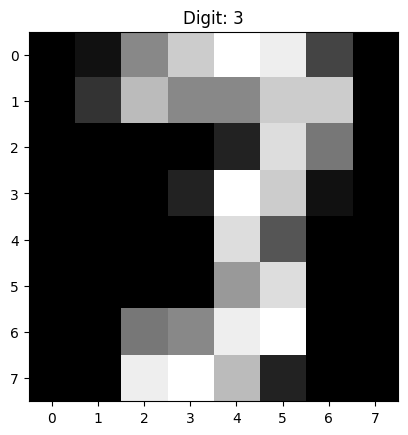

In [ ]:
index = 23
plt.imshow(digits.images[index], cmap='gray')
plt.title(f"Digit: {digits.target[index]}")
plt.show()

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [ ]:
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [ ]:
X_train = torch.tensor(X_train, dtype=torch.float32)
X_test = torch.tensor(X_test, dtype=torch.float32)
y_train = torch.tensor(y_train, dtype=torch.long)
y_test = torch.tensor(y_test, dtype=torch.long)

In [ ]:
from torch.utils.data import DataLoader, TensorDataset

In [ ]:
train_dataset = TensorDataset(X_train,y_train)
test_dataset = TensorDataset(X_test,y_test)

batchsize=16
train_loader = DataLoader(train_dataset, batch_size=batchsize, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=batchsize, shuffle=False)

In [ ]:
model = nn.Sequential(
    nn.Linear(64,128),
    nn.ReLU(),
    nn.Linear(128,64),
    nn.ReLU(),
    nn.Linear(64,10)
    )

criterion = nn.CrossEntropyLoss()
optimizer = optim.SGD(model.parameters(), lr=0.01)

In [ ]:
epochs = 10

for epoch in range(epochs):
  total_loss = 0

  for X_batch,y_batch in train_loader:
    output = model(X_batch)
    loss = criterion(output, y_batch)

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    total_loss += loss.item()

  avg_loss = total_loss / len(train_loader)

  print(f"Epoch:{epoch+1}, Loss:{avg_loss}")

Epoch:1, Loss:0.12628256608214644
Epoch:2, Loss:0.11797770081708829
Epoch:3, Loss:0.1097842554251353
Epoch:4, Loss:0.10305475431183973
Epoch:5, Loss:0.09681583535340098
Epoch:6, Loss:0.091125513240695
Epoch:7, Loss:0.08625997375282976
Epoch:8, Loss:0.08176079614915782
Epoch:9, Loss:0.0772408355648319
Epoch:10, Loss:0.07347344946530131


In [ ]:
def calculate_acc(model, loader):
  model.eval()
  total = 0
  correct = 0

  with torch.no_grad():
    for X_batch,y_batch in loader:
      pred = torch.argmax(model(X_batch),dim=1)
      correct += (pred == y_batch).sum().item()
      total += y_batch.size(0)

  acc = correct / total * 100
  return acc

In [ ]:
train_acc = calculate_acc(model,train_loader)
test_acc = calculate_acc(model,test_loader)

print("Train Accuracy:", train_acc, "%")
print("Test Accuracy :", test_acc, "%")

Train Accuracy: 99.09533750869868 %
Test Accuracy : 96.94444444444444 %
